# 10. The tricritical NNN model

The model is given by

$$ H \;=\; -\sum_i\big(Z_iZ_{i+1} + X_i\big)\;+\;\lambda\sum_i\big(X_iZ_{i+1}Z_{i+2}+Z_iZ_{i+1}X_{i+2}\big) $$

This is the O'Brien–Fendley chain (PRL **120**, 206403, 2018; [arXiv:1712.06662](https://arxiv.org/abs/1712.06662)).
It has the same Alcaraz's convention (field on $X$, order parameter on $Z$) so the disordered free-BC
initial state is again $|X+\rangle$. The three-spin terms are NNN-range (sites $i,i\!+\!1,i\!+\!2$) and the model is self-dual.

*Note:* A quench from a "disordered" (field-polarized) state to the critical point produces the free-BC conformal boundary condition (fast convergence). A quench from an "ordered" state gives fixed BC (slow convergence).

The phase diagram is given by the following table:

| $\lambda$ | phase | central charge |
|---|---|---|
| $0$ | critical TFIM (Ising) | $c=1/2$ |
| $0<\lambda<\lambda_c$ | self-dual Ising critical line | $c=1/2$ |
| $\lambda_c\approx0.428$ | tricritical Ising point | $c=7/10$ |
| $\lambda>\lambda_c$ | gapped (order-disorder coexistence) | — |

This model has a critical line ending at a tricritical point
where $c$ jumps from $1/2$ to $7/10$ (and then drops to zero).

Objectives we aim to answer in this notebook:

1. Does equilibrium DMRG reproduce the Ising line ($c=1/2$) and the tricritical point ($c=7/10$)? What value do we get for $\lambda_c$?
2. Does the temporal entropy after a quench to criticality form the same conformal dome, and does it read $c=7/10$ at the tricritical point?
3. Does the transfer-matrix gap close (entanglement barrier / emergent dual unitarity) as for Alcaraz, and does it close faster at the more-entangled tricritical point?

We use both power methods: the single-vector RTM `powermethod_lr` (cheap, our primary entropy) and the block method `block_transfer_eigs` ($k=4$, which gives the gap and a physical-$\lambda_0$ cross-check).

In [5]:
include("../src/thesislib.jl")
using JLD2, Printf, LsqFit, Plots
gr()

const DT      = 0.1
const NBETA   = 4
const Λ_ISING = 0.0      # critical TFIM
const Λ_TRI   = 0.428    # tricritical point

println("Tricritical (O'Brien–Fendley) model.  dt=$DT  nbeta=$NBETA")
println("  calibration λ=$Λ_ISING  (Ising, c=1/2)")
println("  headline    λ=$Λ_TRI    (tricritical, c=7/10)")

## Locating the tricritical Ising (TCI) point

We map the equilibrium phase diagram by running ground-state DMRG at each $\lambda$ and fit the bond entanglement entropy to the Calabrese–Cardy chord law:

$$ S(\ell) \;=\; \frac{c}{6}\,\log\!\Big[\frac{2N}{\pi}\sin\frac{\pi\ell}{N}\Big] + \text{const}, $$

reading $c$ off the slope. We expect $c\approx1/2$ along the Ising line, a rise toward $7/10$ near $\lambda_c\approx0.428$, and a drop once the system gaps out ($\lambda>\lambda_c$).

> **Finite-size caveat.** Tricritical points carry strong logarithmic corrections, so a single-$N$ fit
> *undershoots* $7/10$ right at $\lambda_c$; the robust signal is the clear **rise above $1/2$**.

In [6]:
# von Neumann entropy across every bond of an MPS
function vn_entropy(psi::MPS)
    N = length(psi); S = Float64[]
    for b in 1:N-1
        orthogonalize!(psi, b)
        ib = b == 1 ? (siteind(psi,b),) : (linkind(psi,b-1), siteind(psi,b))
        _, Sv, _ = svd(psi[b], ib); s = 0.0
        for n in 1:dim(Sv,1)
            pr = Sv[n,n]^2;  pr > 1e-12 && (s -= pr*log(pr))
        end
        push!(S, s)
    end
    return S
end

# ground state at coupling λ on N sites
function tricritical_gs(λ, N)
    sites = siteinds("S=1/2", N)
    H = MPO(tricritical_opsum(N, λ), sites)
    _, psi = dmrg(H, randomMPS(sites, 10); nsweeps=24, maxdim=[20,50,100,200,400,600,800],
                  cutoff=[1e-11], noise=[1e-4,1e-5,1e-6,1e-7,0.0], outputlevel=0)
    return psi
end

tricritical_gs (generic function with 1 method)

λ=0.000   c=0.502
λ=0.050   c=0.503
λ=0.100   c=0.507
λ=0.150   c=0.506
λ=0.200   c=0.509
λ=0.250   c=0.508
λ=0.300   c=0.517
λ=0.350   c=0.545
λ=0.370   c=0.559
λ=0.380   c=0.580
λ=0.390   c=0.597
λ=0.400   c=0.630
λ=0.410   c=0.827
λ=0.420   c=1.118
λ=0.430   c=0.396
λ=0.440   c=0.003
λ=0.450   c=0.000
λ=0.500   c=-0.000
λ=0.550   c=-0.000
λ=0.600   c=-0.000
Tricritical candidate λ_c ≈ 0.42  (peak single-N c = 1.118, an overshoot of 7/10)


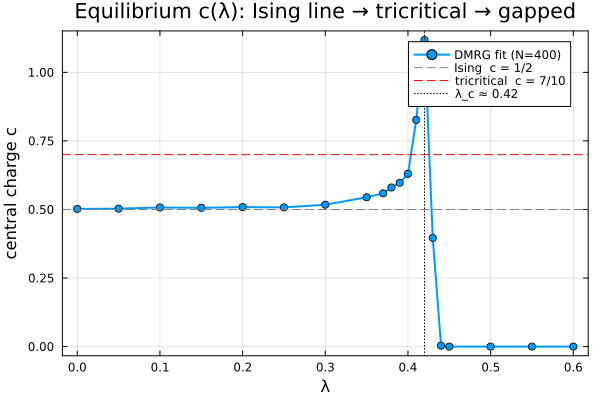

In [ ]:
# central charge from the chord fit of the bulk entropy profile (single N)
@. chord(x, q) = (q[1]/6)*x + q[2]
function c_from_profile(psi)
    N = length(psi)
    bonds = collect(1:N-1)
    S  = vn_entropy(psi)
    xv = log.((2N/pi) .* sin.(pi .* bonds ./ N))
    bulk = findall(b -> N/4 <= b <= 3N/4, bonds)
    return curve_fit(chord, xv[bulk], S[bulk], [1.0, 1.0]).param[1]
end

N_DMRG    = 400
RECOMPUTE = true    # true: delete this N's cache and rebuild from scratch
DMRGFILE  = "../results/data/nb10_tricritical_dmrg_N$(N_DMRG).jld2"

RECOMPUTE && isfile(DMRGFILE) && rm(DMRGFILE)

function tricritical_c_sweep(; N=N_DMRG, λs=sort([0.0:0.05:0.6; 0.37:0.01:0.44]))
    # reload any already computed λ's from the cache file, and skip them
    done    = isfile(DMRGFILE) ? load(DMRGFILE, "res") : Dict{Float64,Float64}()
    have(λ) = any(abs(k - λ) < 1e-6 for k in keys(done))
    for λ in λs
        have(λ) && continue
        done[λ] = c_from_profile(tricritical_gs(λ, N))
        @printf("λ=%.3f   c=%.3f\n", λ, done[λ]); flush(stdout)
        jldsave(DMRGFILE; res=done)
    end
    return done
end

res = tricritical_c_sweep()

λv  = sort(collect(keys(res)))
cv = [res[λ] for λ in λv]

# tricritical point = largest-c point still in the critical phase (before c collapses to 0)
crit = [(λ, c) for (λ, c) in zip(λv, cv) if c > 0.45]
λ_c  = isempty(crit) ? NaN : crit[argmax(last.(crit))][1]
@printf("Tricritical candidate λ_c ≈ %.2f  (peak single-N c = %.3f, an overshoot of 7/10)\n",
        λ_c, maximum(cv))

fig = plot(λv, cv; marker=:circle, lw=2, label="DMRG fit (N=400)", xlabel="λ", ylabel="central charge c",
           framestyle=:box, grid=true, title="Equilibrium c(λ): Ising line → tricritical → gapped")
hline!(fig, [0.5]; ls=:dash, color=:gray, label="Ising  c = 1/2")
hline!(fig, [0.7]; ls=:dash, color=:red,  label="tricritical  c = 7/10")
vline!(fig, [λ_c]; ls=:dot, color=:black, label="λ_c ≈ $(round(λ_c, digits=2))")
mkpath("../results/imgs"); savefig(fig, "../results/imgs/tricritical_c_equilibrium.png"); fig


A single-$N$ chord fit overshoots $c$ near $\lambda_c$ (subleading corrections inflate the slope), so we use finite-size scaling instead.

At $\lambda_c$ the half-chain entanglement entropy obeys the OBC prediction:

$$S(N/2) = \frac{c}{6}\,\ln\!\left(\frac{2N}{\pi}\right) + \text{const}.$$

Fitting $S(N/2)$ vs $\ln(2N/\pi)$ across several $N$ gives slope $= c/6$, hence $c = 6 \times \text{slope} \to 7/10$ at the tricritical point.


finite-size scaling at λ=0.40  →  c = 0.951   (tricritical 7/10 = 0.700)


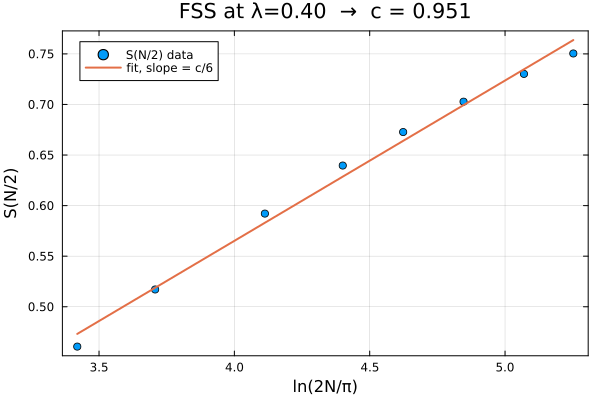

In [13]:
# λ_fss = λ_c  
λ_fss = 0.400    
Ns    = [48, 64, 96, 128, 160, 200, 250, 300]
ys    = [vn_entropy(tricritical_gs(λ_fss, N))[N÷2] for N in Ns]
xs    = [log(2N/pi) for N in Ns]

@. lin(x, q) = q[1]*x + q[2]
fit   = curve_fit(lin, xs, ys, [0.1, 0.1])
cfss  = 6 * fit.param[1]
@printf("finite-size scaling at λ=%.2f  →  c = %.3f   (tricritical 7/10 = 0.700)\n", λ_fss, cfss)

scatter(xs, ys; label="S(N/2) data", xlabel="ln(2N/π)", ylabel="S(N/2)", framestyle=:box,
        legend=:topleft, title=@sprintf("FSS at λ=%.2f  →  c = %.3f", λ_fss, cfss))
plot!(xs, lin.(xs, Ref(fit.param)); lw=2, label="fit, slope = c/6")


### Independent cross-checks for λ_c (the single-N chord fit is unreliable here)

The λ-sweep above is **not trustworthy near the transition**: the peak height does not
shrink between N=200 and N=400 (c≈1.14 → c≈1.12 at λ=0.42), which rules out ordinary
finite-size noise. Instead, the bulk chord fit is contaminated by the crossover between
critical and gapped behavior happening *inside* the N/4–3N/4 fit window — a bias that
does not go away by increasing N at fixed λ.

Two independent diagnostics that don't share this bias:

1. **Finite-size scaling at fixed λ** — sweep N (not λ) and fit S(N/2) vs ln(2N/π).
   At the true λ_c this stays a straight line out to large N with slope → 7/60 ≈ 0.117
   (c=0.7). Off-critical λ shows visible *curvature* (saturation) at larger N even if
   small-N points look fine. This is the direct companion to the c-extraction above.

2. **Finite-size gap scaling** — independent of entanglement entirely. For *any*
   gapless point (Ising line λ<λ_c, or the tricritical point itself), the energy gap
   closes as E₁−E₀ ≈ 2πvx/N, so **N·gap plateaus** as N grows. Past λ_c (gapped phase)
   the gap saturates to a nonzero constant, so **N·gap diverges linearly with N**. This
   doesn't distinguish c=1/2 from c=7/10 (both gapless), but it cleanly **brackets**
   where the gapless region ends — a model-free sanity check on where λ_c can possibly
   be, with none of the chord-fit's bias.


In [ ]:
@. lin(x, q) = q[1]*x + q[2]

function fss_candidate(λ; Ns=[48,64,96,128,160,200,300,400])
    xs = Float64[]; ys = Float64[]
    for N in Ns
        iseven(N) || (N += 1)
        S = vn_entropy(tricritical_gs(λ, N))
        push!(xs, log(2N/pi)); push!(ys, S[N÷2])
        @printf("  λ=%.3f  N=%-4d  S(N/2)=%.4f\n", λ, N, S[N÷2]); flush(stdout)
    end
    fit = curve_fit(lin, xs, ys, [0.1, 0.1])
    c = 6 * fit.param[1]
    resid = ys .- lin.(xs, Ref(fit.param))
    curvature = maximum(abs.(resid))           # how badly it deviates from a straight line
    return (c=c, curvature=curvature, xs=xs, ys=ys)
end

for λ in [0.39, 0.40, 0.41, 0.42, 0.43]
    r = fss_candidate(λ)
    @printf("λ=%.3f  →  c=%.3f   max|resid|=%.4f\n", λ, r.c, r.curvature)
end


In [ ]:
GAPFILE = "../results/data/nb10_tricritical_gap.jld2"

# ground + first excited state via DMRG (orthogonality enforced with `weight`)
function tricritical_gap(λ, N; nsweeps=20, maxdim=[10,20,100,200,400], cutoff=1e-10, weight=20.0)
    sites = siteinds("S=1/2", N)
    H = MPO(tricritical_opsum(N, λ), sites)
    E0, psi0 = dmrg(H, randomMPS(sites, 10); nsweeps=nsweeps, maxdim=maxdim,
                     cutoff=[cutoff], noise=[1e-4,1e-5,1e-6,0.0], outputlevel=0)
    E1, psi1 = dmrg(H, [psi0], randomMPS(sites, 10); nsweeps=nsweeps, maxdim=maxdim,
                     cutoff=[cutoff], noise=[1e-4,1e-5,1e-6,0.0], weight=weight, outputlevel=0)
    return E0, E1, E1 - E0
end

# crash-safe sweep: N·gap(N) for a few candidate λ, keyed by (λ, N)
function gap_sweep(; λs=[0.30, 0.40, 0.41, 0.42, 0.43, 0.50], Ns=[48, 64, 96, 128, 160, 200])
    done = isfile(GAPFILE) ? load(GAPFILE, "res") : Dict{Tuple{Float64,Int},Float64}()
    have(λ, N) = haskey(done, (λ, N))
    for λ in λs, N in Ns
        have(λ, N) && continue
        _, _, gap = tricritical_gap(λ, N)
        done[(λ, N)] = gap
        @printf("λ=%.3f  N=%-4d  gap=%.5f  N·gap=%.4f\n", λ, N, gap, N*gap); flush(stdout)
        jldsave(GAPFILE; res=done)
    end
    return done
end

res = gap_sweep()

fig = plot(xlabel="N", ylabel="N · gap", framestyle=:box, grid=true, legend=:topleft,
           title="Finite-size gap scaling: plateau = gapless, growth = gapped")
for λ in sort(unique(first.(keys(res))))
    Ns_λ  = sort([N for (l, N) in keys(res) if l == λ])
    vals  = [N * res[(λ, N)] for N in Ns_λ]
    plot!(fig, Ns_λ, vals; marker=:circle, lw=2, label="λ=$λ")
end
mkpath("../results/imgs"); savefig(fig, "../results/imgs/tricritical_gap.png"); fig

## Temporal-entropy master sweep (dynamics)

We quench $|X+\rangle$ with $H(\lambda)$ at the critical couplings and contract the network transversally. For every $(\lambda, T)$ we run both power methods:

* single-vector RTM (`powermethod_lr`) to get the entropy domes
* block method (`block_transfer_eigs` with $k=4$) to get the gap + a physical-$\lambda_0$ Rényi-2 dome as an indep cross-check

Note: each $T$-ladder is warm-started from the previous $T$'s fixed point.

In [2]:
MASTER   = "../results/data/nb10_tricritical_master.jld2"
λ_list   = [Λ_ISING, Λ_TRI]            # add more couplings here; only missing points are recomputed
T_ladder = collect(2.0:1.0:10.0)
MAXDIM   = 64

# Pick the physical λ0 among the two leading eigenvalues: the one continuous with the previous T
# (the −λ0 partner sits ≈π away in phase). Returns (i_physical, i_partner). Same selector as nb7.
pick_phys(θ, prev) = prev === nothing ? (1, 2) :
                     (abs(θ[1]-prev) <= abs(θ[2]-prev) ? (1, 2) : (2, 1))

half = NBETA ÷ 2
trim(v) = v[half+1:end-half]           # drop the nbeta/2 cooling bonds at each end

function tricritical_master_sweep()
    done = isfile(MASTER) ? load(MASTER, "done") : Dict{Tuple{Float64,Float64},Any}()
    for λ in λ_list
        mp = TricriticalParams(lambda=λ)
        seed_sv = nothing                       # single-vector warm start (previous-T |R⟩)
        seedL = seedR = nothing                 # block warm start (previous-T k-blocks)
        prev_phys = nothing
        for T in T_ladder
            if haskey(done, (λ,T)) && !haskey(done[(λ,T)], :error)
                prev_phys = get(done[(λ,T)], :theta_phys, nothing)
                seed_sv = nothing; seedL = seedR = nothing      # can't warm from a cached (unloaded) vector
                continue
            end
            try
                # ── single-vector RTM power method → Rényi-2 dome ───────────────────────────────
                rv = compute_entropies(mp, T; scheme=TricriticalVD2(), init_state="X+",
                        dt=DT, nbeta=NBETA, maxdim=MAXDIM, maxdims=collect(2:2:MAXDIM),
                        itermax=4000, stuck_after=600, seed=seed_sv)

                # ── block PM k=4 → eigenvalues (gap) + physical-λ0 Rényi-2 dome ─────────────────
                mpo, scaf = build_tmpo(mp, TricriticalVD2(), T; dt=DT, nbeta=NBETA, init_state="X+")
                sit = siteinds(scaf)
                sL = seedL === nothing ? nothing : MPS[pad_tmps(w, sit) for w in seedL]
                sR = seedR === nothing ? nothing : MPS[pad_tmps(w, sit) for w in seedR]
                θ, L, R, info = block_transfer_eigs(mpo, scaf; k=4, maxdim=MAXDIM,
                        maxdims=collect(2:2:MAXDIM), cutoff=1e-12, cutoffs=[fill(1e-8,40); 1e-10],
                        itermax=8000, eps_conv=1e-6, trunc_mode=:rtm, n_track=2,
                        stuck_after=400, seedL=sL, seedR=sR)
                i0, ip = pick_phys(θ, prev_phys)
                s2_blk = trim(ITransverse.gen_renyi2(L[i0], R[i0]))

                done[(λ,T)] = (lambda=λ, T=T,
                    re_sv  = trim(rv.re), im_sv  = trim(rv.im),        # single-vector dome
                    re_blk = real.(s2_blk), im_blk = imag.(s2_blk),    # block physical-λ0 dome
                    theta  = collect(θ), i0=i0, ip=ip, theta_phys=θ[i0],
                    reason = string(info[:reason]), niters = info[:niters], chi = maxlinkdim(rv.R))

                prev_phys = θ[i0];  seed_sv = rv.R;  seedL, seedR = L, R   # warm-start next T
                @printf("λ=%.3f T=%2.0f | |λ0|=%.4f  Re-peak sv=%.3f blk=%.3f | block %d it (%s)\n",
                        λ, T, abs(θ[i0]), maximum(trim(rv.re)), maximum(real.(s2_blk)),
                        info[:niters], info[:reason]); flush(stdout)
            catch err
                @warn "λ=$λ T=$T failed: $err"
                done[(λ,T)] = (error=string(err),)
                seed_sv = nothing; seedL = seedR = nothing; prev_phys = nothing
            end
            jldsave(MASTER; done=done); GC.gc()                 # checkpoint after every point
        end
    end
    return done
end

done = tricritical_master_sweep()
println("\ncached points: ", sort([k for k in keys(done) if !haskey(done[k], :error)]))

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=985|"S=1/2,Site") <-> (dim=2|id=985|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=7|id=965|"Link,l=1") <-> (dim=7|id=313|"Link,l=2"), normdiff = 3.674388927640873
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=602|"S=1/2,Site") <-> (dim=2|id=602|

λ=0.428 T= 4 | |λ0|=1.5256  Re-peak sv=0.717 blk=0.718 | block 534 it (stuck)


┌ Warning: norm² is 1.7360760489483598 - 4.163336342344337e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS /home/jmarquezol/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=543|"S=1/2,Site") <-> (dim=2|id=543|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=7|id=373|"Link,l=1") <-> (dim=7|id=424|"Link,l=2"), normdiff = 3.674388927640873
└ @ ITransverse /home

λ=0.428 T= 5 | |λ0|=1.5085  Re-peak sv=0.698 blk=1.178 | block 462 it (stuck)


┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=104|"S=1/2,Site") <-> (dim=2|id=104|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=7|id=620|"Link,l=1") <-> (dim=7|id=365|"Link,l=2"), normdiff = 3.674388927640873
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=692|"S=1/2,Site") <-> (dim=2|id=692|

InterruptException: InterruptException:

## 3. The temporal-entropy domes

If the quench is conformal, $\mathrm{Re}\,S_2(t)$ traces a logarithmic **dome** over $[0,T]$ that grows
with $T$, while $\mathrm{Im}\,S_2$ sits on a universal plateau. The single-vector and block
(physical-$\lambda_0$) routes should agree until the gap closes. We show the tricritical point.

In [4]:
done = load(MASTER, "done")
gotT(λ) = sort([T for (l,T) in keys(done) if l==λ && haskey(done[(l,T)], :re_sv)])

λshow = Λ_TRI
Ts    = gotT(λshow)
pal   = cgrad(:viridis, max(length(Ts),2), categorical=true)
xs(v) = (1:length(v)) ./ (length(v)+1)                 # bond index → t/T ∈ (0,1)

pR = plot(title="Re S₂ — single-vector  (λ=$λshow)", xlabel="t/T", ylabel="Re S₂",
          framestyle=:box, legend=:bottomright)
pB = plot(title="Re S₂ — block physical-λ₀  (λ=$λshow)", xlabel="t/T", ylabel="Re S₂",
          framestyle=:box, legend=:bottomright)
for (k,T) in enumerate(Ts)
    e = done[(λshow,T)]
    plot!(pR, xs(e.re_sv),  e.re_sv;  color=pal[k], lw=2, label="T=$(Int(T))")
    plot!(pB, xs(e.re_blk), e.re_blk; color=pal[k], lw=2, label="T=$(Int(T))")
end
plt = plot(pR, pB; layout=(1,2), size=(1200,460), margin=5Plots.mm)
mkpath("../results/imgs"); savefig(plt, "../results/imgs/tricritical_entropy_profiles.png"); plt

InterruptException: InterruptException:

## 4. The central charge from the chord slope

For the Rényi-2 generalized temporal entropy the conformal prediction is

$$ \mathrm{Re}\,S_2(t) \;=\; s_0 + \frac{c}{8}\,\log\!\Big[\frac{2T}{\pi}\sin\frac{\pi t}{T}\Big], $$

so $c = 8\times(\text{slope})$ against the chord variable $\log\sin(\pi t/T)$. To cancel the
scheme-dependent prefactor we report the **calibrated** value
$c(\lambda)=\tfrac12\,\mathrm{slope}(\lambda)/\mathrm{slope}(\Lambda_{\rm ISING})$, anchored to the exact
Ising $c=1/2$. The tricritical target $c=7/10$ corresponds to a slope ratio of $1.4$.

In [5]:
# slope of Re S2 vs the conformal chord, using the central half of the dome (avoid the tips)
function chord_slope(re)
    nb = length(re)
    x  = [log(sin(pi*j/(nb+1))) for j in 1:nb]          # chord variable (constant log(2T/π) ⊂ s0)
    m  = findall(j -> nb÷4 <= j <= 3nb÷4, 1:nb)
    @. lin(x,q) = q[1]*x + q[2]
    return curve_fit(lin, x[m], re[m], [1.0, 0.0]).param[1]
end

println("calibrated  c(λ) = 0.5 · slope(λ) / slope(Ising):\n")
@printf("%-5s | %-18s %-18s | %s\n", "T", "raw 8·slope Ising", "raw 8·slope tri", "calibrated c(tri)")
for Tref in T_ladder
    (haskey(done,(Λ_ISING,Tref)) && haskey(done,(Λ_TRI,Tref))) || continue
    (haskey(done[(Λ_ISING,Tref)], :re_sv) && haskey(done[(Λ_TRI,Tref)], :re_sv)) || continue
    s0 = chord_slope(done[(Λ_ISING,Tref)].re_sv)
    s1 = chord_slope(done[(Λ_TRI,Tref)].re_sv)
    @printf("%-5.0f | %-18.3f %-18.3f | %.3f\n", Tref, 8s0, 8s1, 0.5*s1/s0)
end

## 5. The transfer-matrix gap

The block method gives the four leading eigenvalues $\theta_i$ of the (rotated) transfer matrix. As in
the Alcaraz study the spectrum comes in $\pm$ pairs, so we report the **physical gap**
$|\lambda_1|/|\lambda_0|$ — the next *distinct* eigenvalue over the physical $\lambda_0$, skipping the
$-\lambda_0$ partner. A gap closing toward $1$ is the entanglement barrier / emergent dual unitarity;
we expect it to close **faster** at the more-entangled tricritical point.

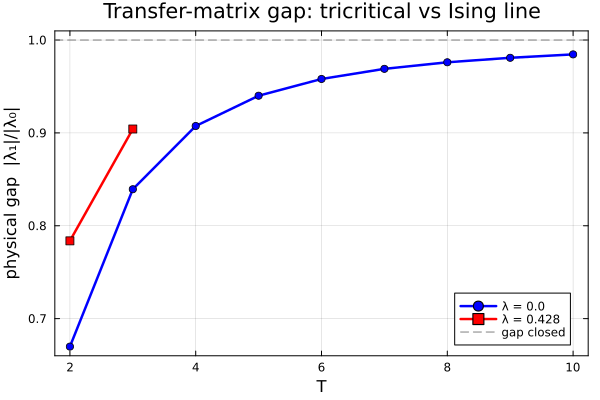

In [6]:
# physical gap: λ1 = largest |θ| that is neither the physical λ0 (i0) nor its −λ0 partner (ip)
function phys_gap(e)
    θ = e.theta; others = [j for j in eachindex(θ) if j != e.i0 && j != e.ip]
    return maximum(abs.(θ[others])) / abs(θ[e.i0])
end
gapline(λ) = (Tg = sort([T for (l,T) in keys(done) if l==λ && haskey(done[(l,T)], :theta)]);
              (Tg, [phys_gap(done[(λ,T)]) for T in Tg]))

pg = plot(xlabel="T", ylabel="physical gap  |λ₁|/|λ₀|", framestyle=:box, grid=true,
          legend=:bottomright, title="Transfer-matrix gap: tricritical vs Ising line")
for (λ, col, mk) in [(Λ_ISING, :blue, :circle), (Λ_TRI, :red, :square)]
    Tg, g = gapline(λ)
    isempty(Tg) && continue
    plot!(pg, Tg, g; marker=mk, lw=2.5, color=col, label="λ = $λ")
end
hline!(pg, [1.0]; ls=:dash, color=:gray, label="gap closed")
mkpath("../results/imgs"); savefig(pg, "../results/imgs/tricritical_gap.png"); pg

## Verdict

*(fill in the measured numbers after running the master sweep)*

* **Equilibrium.** DMRG should give $c\approx1/2$ along the Ising line and a clear rise toward $7/10$
  near $\lambda_c\approx0.428$ (modulo the finite-size undershoot).
* **Temporal.** If the calibrated chord slope at $\lambda_{\rm tri}$ is $\approx1.4\times$ the Ising
  slope, the *temporal* central charge reproduces $c=7/10$ — the transverse method then sees the
  **tricritical** universality, not merely Ising.
* **Gap.** The entanglement barrier should close *faster* at the tricritical point (more entanglement
  ⇒ the wall arrives at smaller $T$ ⇒ a shorter $T$-reach than along the Ising line), mirroring the
  "frustration closes the gap faster" lesson from Alcaraz.